In [1]:
import numpy as np 
import pandas as pd 

In [2]:
df = pd.read_csv('data/processed/clean_router_data.csv')

In [3]:
df.head()

,query_id,prompt,eval_name,claude_instant_score,claude_v1_score,claude_v2_score,code_llama_34b_score,gpt_35_turbo_score,gpt_4_score,llama_2_70b_score,...,claude_v2_tokens,code_llama_34b_tokens,gpt_35_turbo_tokens,gpt_4_tokens,llama_2_70b_tokens,mistral_7b_tokens,mixtral_8x7b_tokens,wizardlm_13b_tokens,yi_34b_tokens,prompt_tokens
0,rb_000000,A binary tree is full if all of its vertices h...,mtbench-reference,0.1,0.2,0.2,0.2,0.3,0.8,0.2,...,463.0,884.0,467.0,991.0,1184.0,586.0,698.0,798.0,951.0,54.0
1,rb_000001,A is the father of B. B is the father of C. Wh...,mtbench-math,0.1,0.1,0.1,0.1,0.3,0.1,0.3,...,162.0,123.0,35.0,408.0,146.0,78.0,354.0,127.0,239.0,87.0
2,rb_000002,A tech startup invests $8000 in software devel...,mtbench-math,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,256.0,103.0,109.0,200.0,155.0,163.0,225.0,225.0,197.0,82.0
3,rb_000003,Act as a math teacher. I will provide some mat...,mtbench,0.7,1.0,0.9,0.9,1.0,1.0,0.9,...,562.0,928.0,643.0,1444.0,1122.0,697.0,890.0,973.0,995.0,88.0
4,rb_000004,Analyze the following customer reviews from di...,mtbench,0.5,0.9,0.8,0.4,0.9,0.9,0.8,...,441.0,599.0,63.0,747.0,668.0,73.0,344.0,88.0,65.0,353.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36497 entries, 0 to 36496
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   query_id               36497 non-null  object 
 1   prompt                 36497 non-null  object 
 2   eval_name              36497 non-null  object 
 3   claude_instant_score   36483 non-null  float64
 4   claude_v1_score        36483 non-null  float64
 5   claude_v2_score        36483 non-null  float64
 6   code_llama_34b_score   36483 non-null  float64
 7   gpt_35_turbo_score     36483 non-null  float64
 8   gpt_4_score            36483 non-null  float64
 9   llama_2_70b_score      36483 non-null  float64
 10  mistral_7b_score       36483 non-null  float64
 11  mixtral_8x7b_score     36483 non-null  float64
 12  wizardlm_13b_score     36483 non-null  float64
 13  yi_34b_score           36483 non-null  float64
 14  claude_instant_tokens  36483 non-null  float64
 15  cl

In [5]:
!pip install sentence-transformers

   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/740.6 kB ? eta -:--:--
   ---

In [ ]:
import os
from sentence_transformers import SentenceTransformer

CSV_PATH = "data/processed/clean_router_data.csv"
NPY_PATH = "data/processed/X_embeddings.npy"

prompts = df["prompt"].astype(str).tolist()

print("Initializing SentenceTransformer (all-MiniLM-L6-v2)...")
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cpu")

print(f"Encoding {len(prompts):,} prompts. This will take a couple of minutes...")
embeddings = encoder.encode(
    prompts,
    batch_size=128,       
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

np.save(NPY_PATH, embeddings)
print(f"\nSuccessfully saved binary embedding matrix to: {NPY_PATH}")
print(f"Feature matrix shape: {embeddings.shape} | dtype: {embeddings.dtype}")

Initializing SentenceTransformer (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\prana\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\prana\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 36,497 prompts. This will take a couple of minutes...


Batches:   0%|          | 0/286 [00:00<?, ?it/s]


Successfully saved binary embedding matrix to: data/processed/X_embeddings.npy
Feature matrix shape: (36497, 384) | dtype: float32


In [7]:
from sklearn.model_selection import train_test_split

X = np.load("data/processed/X_embeddings.npy")

df = pd.read_csv("data/processed/clean_router_data.csv")

candidates = [
    "claude_instant", "claude_v1", "claude_v2", "code_llama_34b",
    "gpt_35_turbo", "gpt_4", "llama_2_70b", "mistral_7b", 
    "mixtral_8x7b", "wizardlm_13b", "yi_34b"
]

# Y_quality has shape (36497, 11) representing scores between 0.0 and 1.0
Y_quality = df[[f"{c}_score" for c in candidates]].values.astype(np.float32)

# Y_tokens has shape (36497, 11) representing token counts >= 0
Y_tokens = df[[f"{c}_tokens" for c in candidates]].values.astype(np.float32)

print(f"Features (X) shape : {X.shape}")
print(f"Quality (Y) shape  : {Y_quality.shape}")
print(f"Tokens (Y) shape   : {Y_tokens.shape}")

X_train, X_val, Y_q_train, Y_q_val, Y_t_train, Y_t_val = train_test_split(
    X, Y_quality, Y_tokens, test_size=0.2, random_state=42
)

Features (X) shape : (36497, 384)
Quality (Y) shape  : (36497, 11)
Tokens (Y) shape   : (36497, 11)


### MLP Regressor

In [12]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.2-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached ml_dtypes-0.6.0-cp313-cp313-win_amd64.whl.metadata (8.8 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.20.0-cp313-cp313-win_amd64.whl.metadata (33 kB)
   ----------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/26.4 MB ? eta -:--:--
   -----------------

In [13]:
import tensorflow as tf

In [26]:
import tensorflow as tf

def build_quality_model(input_dim=384, num_models=11):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation='gelu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(128, activation='gelu'),
        tf.keras.layers.Dense(num_models, activation='sigmoid', name='quality_out')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=['mae']
    )
    return model

def build_token_model(input_dim=384, num_models=11):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation='gelu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(128, activation='gelu'),
        tf.keras.layers.Dense(num_models, activation='relu', name='token_out')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model

quality_model = build_quality_model()
token_model = build_token_model()

In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

X = np.load("data/processed/X_embeddings.npy")
df = pd.read_csv("data/processed/clean_router_data.csv")

candidates = [
    "claude_instant", "claude_v1", "claude_v2", "code_llama_34b",
    "gpt_35_turbo", "gpt_4", "llama_2_70b", "mistral_7b", 
    "mixtral_8x7b", "wizardlm_13b", "yi_34b"
]

score_cols = [f"{c}_score" for c in candidates]
valid_mask = df[score_cols].notna().all(axis=1)

print(f"Original shape: {df.shape[0]} rows")
print(f"Dropping {(~valid_mask).sum()} rows containing NaNs...")

df_clean = df[valid_mask]
X_clean = X[valid_mask]

Y_quality = df_clean[score_cols].values.astype(np.float32)
Y_tokens = df_clean[[f"{c}_tokens" for c in candidates]].values.astype(np.float32)

X_train, X_val, Y_q_train, Y_q_val, Y_t_train, Y_t_val = train_test_split(
    X_clean, Y_quality, Y_tokens, test_size=0.2, random_state=42
)

quality_model = build_quality_model()
token_model = build_token_model()

callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)]

print("\n--- Training Quality Regressor ---")
history_quality = quality_model.fit(
    X_train, Y_q_train, validation_data=(X_val, Y_q_val),
    epochs=100, batch_size=128, callbacks=callbacks
)

print("\n--- Training Token Length Regressor ---")
history_token = token_model.fit(
    X_train, Y_t_train, validation_data=(X_val, Y_t_val),
    epochs=100, batch_size=128, callbacks=callbacks
)

Original shape: 36497 rows
Dropping 28 rows containing NaNs...

--- Training Quality Regressor ---
Epoch 1/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1670 - mae: 0.3454 - val_loss: 0.1968 - val_mae: 0.4266
Epoch 2/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1622 - mae: 0.3406 - val_loss: 0.1776 - val_mae: 0.3985
Epoch 3/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1612 - mae: 0.3401 - val_loss: 0.1633 - val_mae: 0.3556
Epoch 4/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1607 - mae: 0.3393 - val_loss: 0.1631 - val_mae: 0.3418
Epoch 5/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1603 - mae: 0.3390 - val_loss: 0.1630 - val_mae: 0.3378
Epoch 6/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1599 - mae: 0.3385 - val_loss: 0.1630 - val_mae: 0.3455
Epoch 7/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1597 - mae: 0.3383 - val_loss: 0.1626 - val_mae: 0.3416
Epoch 8/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1596 

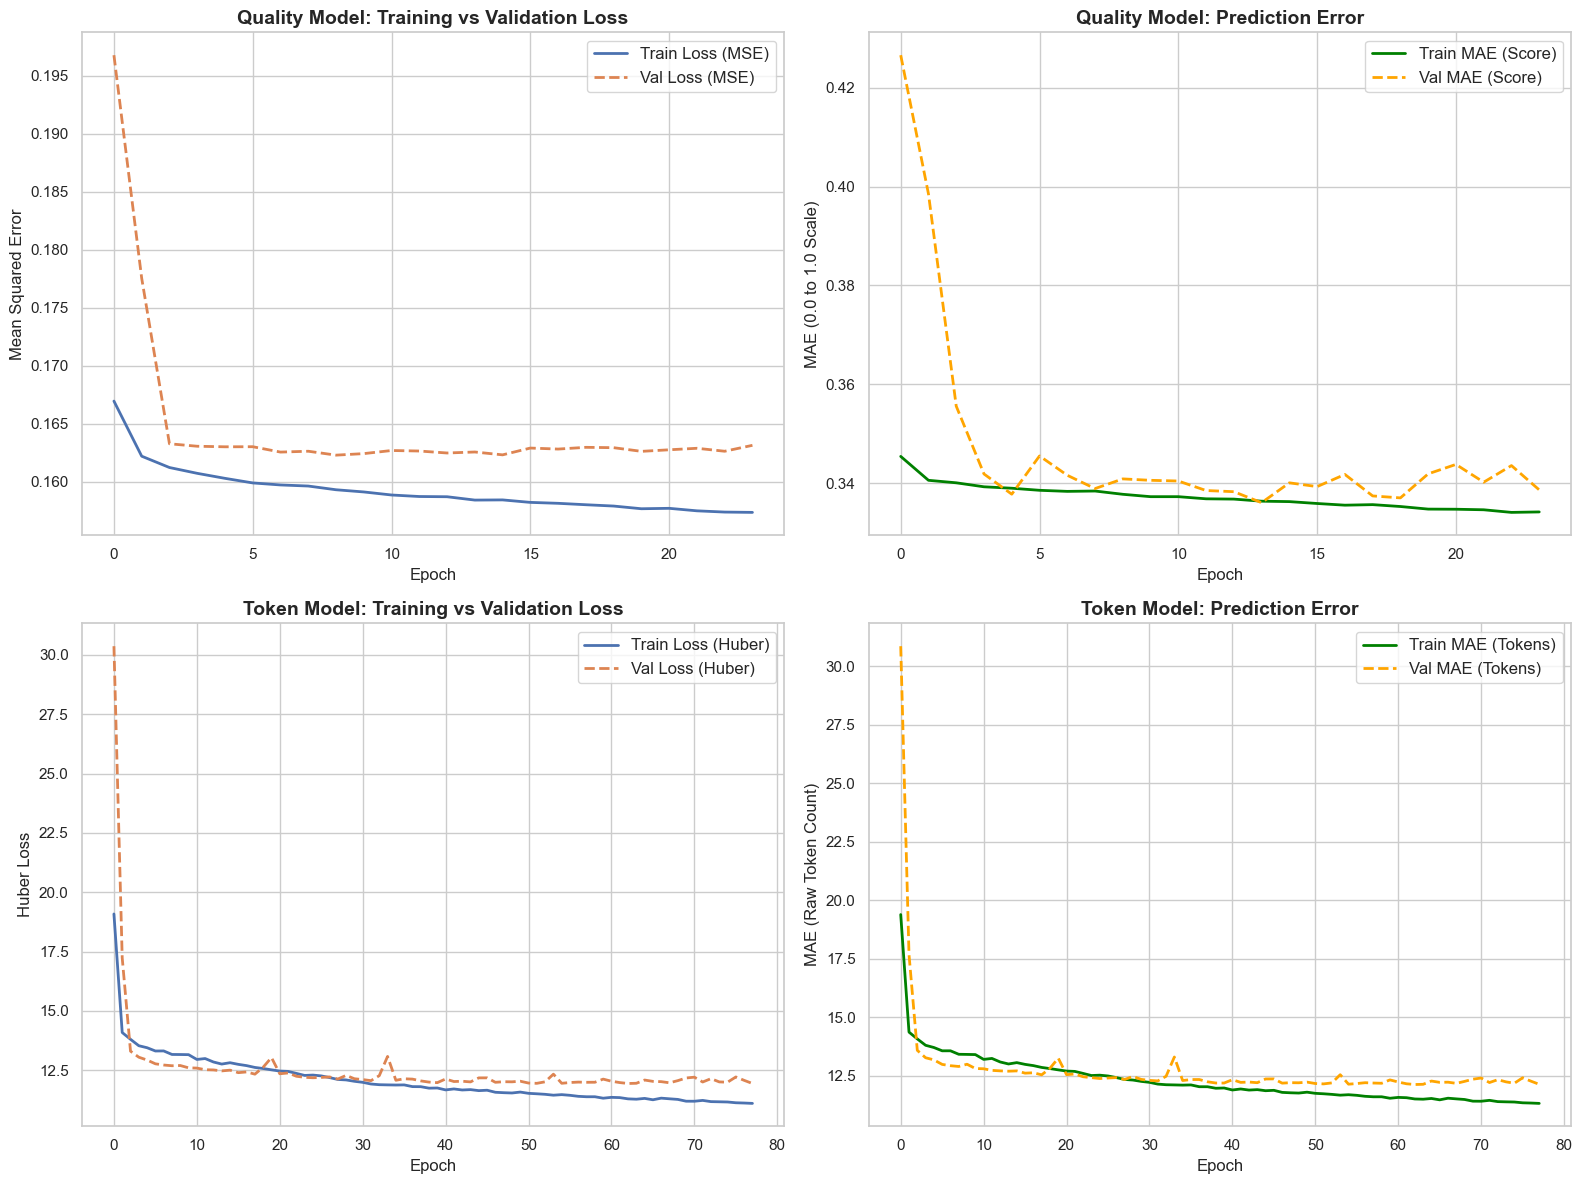

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(history_quality.history['loss'], label='Train Loss (MSE)', linewidth=2)
axes[0, 0].plot(history_quality.history['val_loss'], label='Val Loss (MSE)', linewidth=2, linestyle='--')
axes[0, 0].set_title("Quality Model: Training vs Validation Loss", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Epoch", fontsize=12)
axes[0, 0].set_ylabel("Mean Squared Error", fontsize=12)
axes[0, 0].legend(fontsize=12)

axes[0, 1].plot(history_quality.history['mae'], label='Train MAE (Score)', linewidth=2, color='green')
axes[0, 1].plot(history_quality.history['val_mae'], label='Val MAE (Score)', linewidth=2, color='orange', linestyle='--')
axes[0, 1].set_title("Quality Model: Prediction Error", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Epoch", fontsize=12)
axes[0, 1].set_ylabel("MAE (0.0 to 1.0 Scale)", fontsize=12)
axes[0, 1].legend(fontsize=12)

axes[1, 0].plot(history_token.history['loss'], label='Train Loss (Huber)', linewidth=2)
axes[1, 0].plot(history_token.history['val_loss'], label='Val Loss (Huber)', linewidth=2, linestyle='--')
axes[1, 0].set_title("Token Model: Training vs Validation Loss", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Epoch", fontsize=12)
axes[1, 0].set_ylabel("Huber Loss", fontsize=12)
axes[1, 0].legend(fontsize=12)

axes[1, 1].plot(history_token.history['mae'], label='Train MAE (Tokens)', linewidth=2, color='green')
axes[1, 1].plot(history_token.history['val_mae'], label='Val MAE (Tokens)', linewidth=2, color='orange', linestyle='--')
axes[1, 1].set_title("Token Model: Prediction Error", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Epoch", fontsize=12)
axes[1, 1].set_ylabel("MAE (Raw Token Count)", fontsize=12)
axes[1, 1].legend(fontsize=12)

plt.tight_layout()
plt.show()

In [31]:
# All weights as a list of numpy arrays [W1, b1, gamma1, beta1, ..., W_out, b_out]
all_quality_weights = token_model.get_weights()

# Or access just the final layer's kernel (weights) and bias:
final_weights, final_biases = token_model.layers[-1].get_weights()

print("Final Output Weights Matrix:")
print(final_weights)

print("\nFinal Output Bias Vector:")
print(final_biases)

Final Output Weights Matrix:
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]

Final Output Bias Vector:
[nan nan nan nan nan nan nan nan nan nan nan]


In [ ]:
import os
import numpy as np
import tensorflow as tf

os.makedirs("artifacts", exist_ok=True)

def build_stable_quality_model(input_dim=384, num_models=11):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation='gelu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(128, activation='gelu'),
        tf.keras.layers.Dense(num_models, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=['mae']
    )
    return model

def build_stable_token_model(input_dim=384, num_models=11):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation='gelu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(128, activation='gelu'),
        tf.keras.layers.Dense(num_models, activation='relu')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model

quality_model = build_stable_quality_model()
token_model = build_stable_token_model()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

print("--- Training Quality Regressor ---")
history_quality = quality_model.fit(
    X_train, Y_q_train,
    validation_data=(X_val, Y_q_val),
    epochs=500,
    batch_size=128,
    # callbacks=[early_stop]
)

print("\n--- Training Token Length Regressor ---")
history_token = token_model.fit(
    X_train, Y_t_train,
    validation_data=(X_val, Y_t_val),
    epochs=100,
    batch_size=128,
    # callbacks=[early_stop]
)

quality_model.save("artifacts/quality_model.keras")
token_model.save("artifacts/token_model.keras")
print("\nHealthy models saved to 'artifacts/'.")

--- Training Quality Regressor ---
Epoch 1/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.1669 - mae: 0.3451 - val_loss: 0.1976 - val_mae: 0.4274
Epoch 2/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1623 - mae: 0.3409 - val_loss: 0.1790 - val_mae: 0.4012
Epoch 3/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1611 - mae: 0.3399 - val_loss: 0.1647 - val_mae: 0.3612
Epoch 4/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1607 - mae: 0.3394 - val_loss: 0.1629 - val_mae: 0.3429
Epoch 5/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1603 - mae: 0.3391 - val_loss: 0.1630 - val_mae: 0.3372
Epoch 6/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1600 - mae: 0.3384 - val_loss: 0.1628 - val_mae: 0.3402
Epoch 7/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1597 - mae: 0.3384 - val_loss: 0.1624 - val_mae: 0.3368
Epoch 8/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1594 - mae: 0.3377 - val_loss: 0.1626 - val_mae: 0.3466
Epoch 9/40
228/228 ━

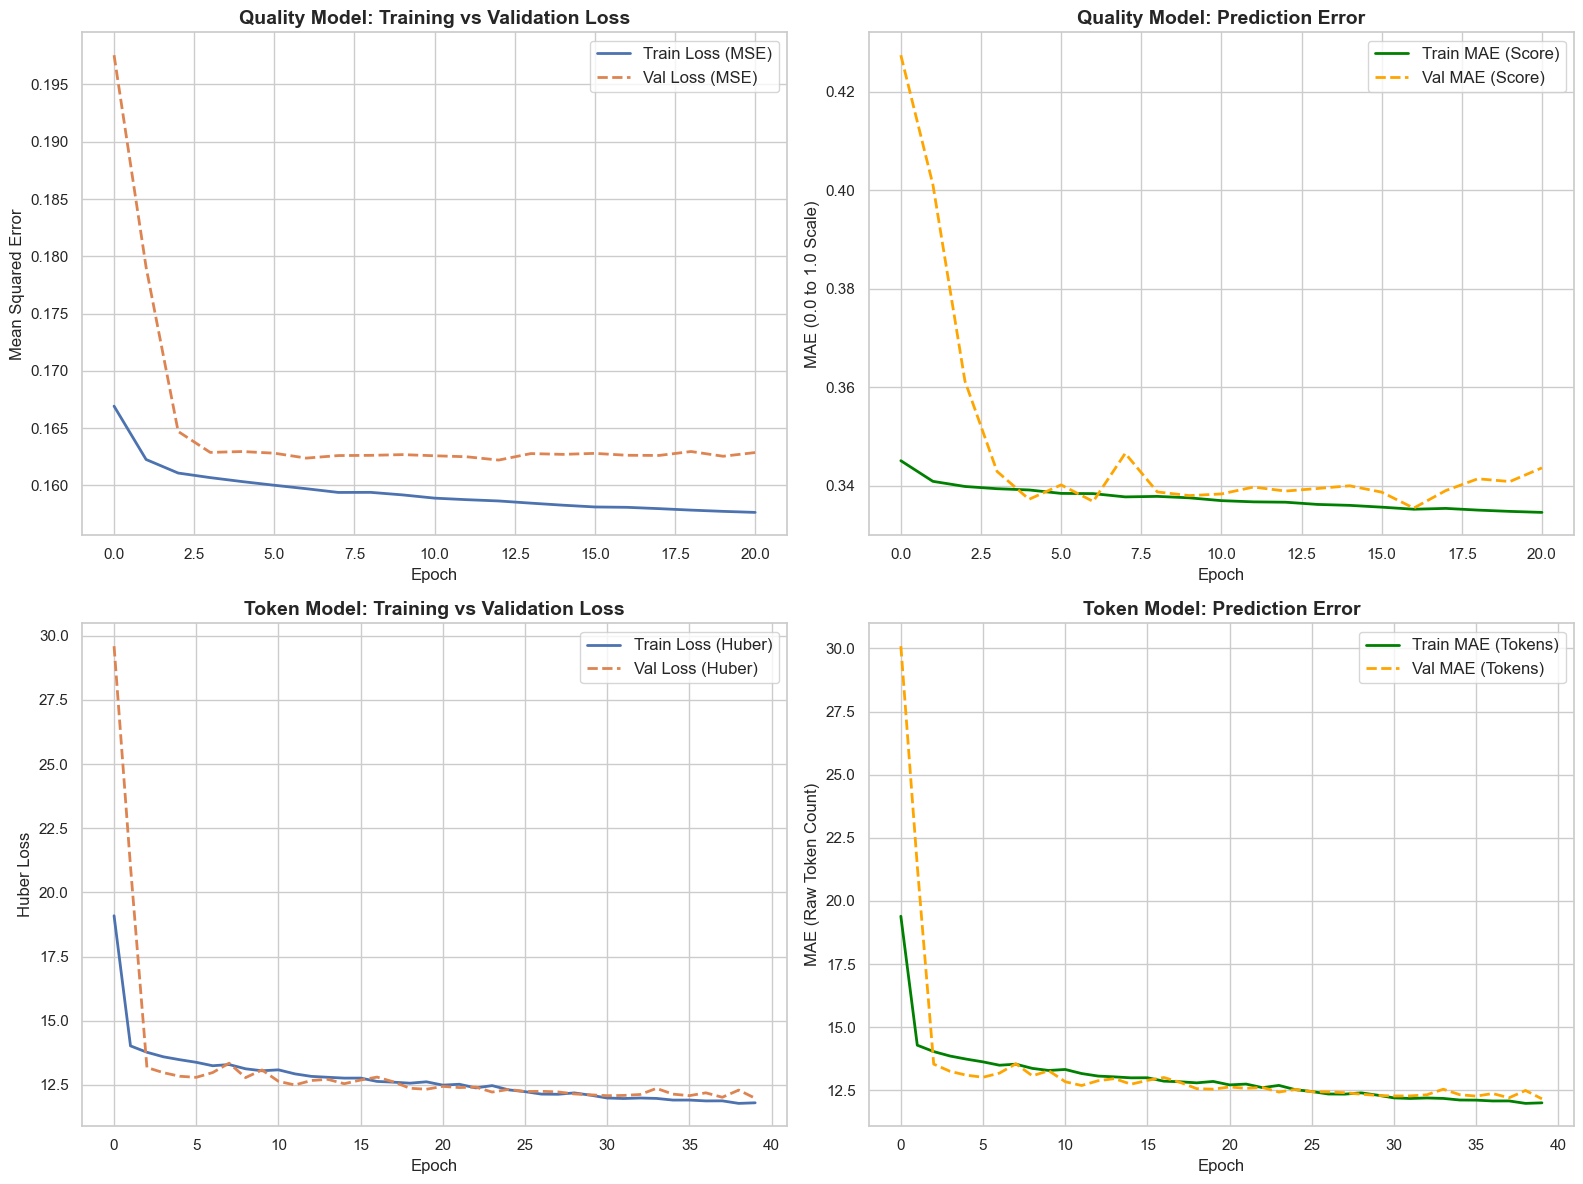

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(history_quality.history['loss'], label='Train Loss (MSE)', linewidth=2)
axes[0, 0].plot(history_quality.history['val_loss'], label='Val Loss (MSE)', linewidth=2, linestyle='--')
axes[0, 0].set_title("Quality Model: Training vs Validation Loss", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Epoch", fontsize=12)
axes[0, 0].set_ylabel("Mean Squared Error", fontsize=12)
axes[0, 0].legend(fontsize=12)

axes[0, 1].plot(history_quality.history['mae'], label='Train MAE (Score)', linewidth=2, color='green')
axes[0, 1].plot(history_quality.history['val_mae'], label='Val MAE (Score)', linewidth=2, color='orange', linestyle='--')
axes[0, 1].set_title("Quality Model: Prediction Error", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Epoch", fontsize=12)
axes[0, 1].set_ylabel("MAE (0.0 to 1.0 Scale)", fontsize=12)
axes[0, 1].legend(fontsize=12)

axes[1, 0].plot(history_token.history['loss'], label='Train Loss (Huber)', linewidth=2)
axes[1, 0].plot(history_token.history['val_loss'], label='Val Loss (Huber)', linewidth=2, linestyle='--')
axes[1, 0].set_title("Token Model: Training vs Validation Loss", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Epoch", fontsize=12)
axes[1, 0].set_ylabel("Huber Loss", fontsize=12)
axes[1, 0].legend(fontsize=12)

axes[1, 1].plot(history_token.history['mae'], label='Train MAE (Tokens)', linewidth=2, color='green')
axes[1, 1].plot(history_token.history['val_mae'], label='Val MAE (Tokens)', linewidth=2, color='orange', linestyle='--')
axes[1, 1].set_title("Token Model: Prediction Error", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Epoch", fontsize=12)
axes[1, 1].set_ylabel("MAE (Raw Token Count)", fontsize=12)
axes[1, 1].legend(fontsize=12)

plt.tight_layout()
plt.show()

In [35]:
# All weights as a list of numpy arrays [W1, b1, gamma1, beta1, ..., W_out, b_out]
all_quality_weights = token_model.get_weights()

# Or access just the final layer's kernel (weights) and bias:
final_weights, final_biases = token_model.layers[-1].get_weights()

print("Final Output Weights Matrix:")
print(final_weights)

print("\nFinal Output Bias Vector:")
print(final_biases)

Final Output Weights Matrix:
[[-0.04267253 -0.02245793 -0.0352617  ...  0.05219385 -0.08372788
  -0.08102192]
 [-0.03904437 -0.08404607  0.2571034  ... -0.15949336  0.38147664
   0.16207996]
 [ 0.21302913  0.1804744   0.12133554 ... -0.01119607  0.17771274
   0.2765786 ]
 ...
 [ 0.05088807  0.16151963  0.29485208 ...  0.20969887  0.3445236
   0.29246244]
 [-0.15098967 -0.2063985  -0.10089646 ... -0.20758526 -0.07079085
  -0.11541005]
 [ 0.14777832  0.16222113  0.24257427 ...  0.2739682   0.02132188
   0.33134952]]

Final Output Bias Vector:
[0.6086107  0.61438173 0.90877104 0.68137825 0.50650036 0.47031608
 0.51378536 0.50699264 0.6365746  0.8610577  0.6717408 ]


In [36]:
# All weights as a list of numpy arrays [W1, b1, gamma1, beta1, ..., W_out, b_out]
all_quality_weights = quality_model.get_weights()

# Or access just the final layer's kernel (weights) and bias:
final_weights, final_biases = quality_model.layers[-1].get_weights()

print("Final Output Weights Matrix:")
print(final_weights)

print("\nFinal Output Bias Vector:")
print(final_biases)

Final Output Weights Matrix:
[[ 0.0186318   0.12877543 -0.06076411 ... -0.00027369 -0.04134572
   0.14954035]
 [-0.02108051 -0.01179072  0.10401902 ...  0.08676977 -0.07936756
   0.01753584]
 [ 0.10182124 -0.02631129  0.02473755 ... -0.01864452  0.1167465
   0.10752232]
 ...
 [-0.05863872 -0.04841792  0.11223844 ... -0.13988242 -0.00082534
  -0.1505555 ]
 [-0.071863    0.03830875 -0.02926088 ... -0.0374183  -0.02449722
   0.05514529]
 [-0.13688134 -0.07357531 -0.15351574 ... -0.06251989  0.06826082
  -0.03767073]]

Final Output Bias Vector:
[ 0.07472041  0.10174693  0.02104758  0.01468354  0.1695164   0.23354268
  0.0727492  -0.0289572   0.11137402  0.03047595  0.14032118]


In [41]:
import numpy as np
import tensorflow as tf

# 1. Apply Log1p transform to squash the extreme outliers
Y_t_train_log = np.log1p(Y_t_train)
Y_t_val_log = np.log1p(Y_t_val)

print(f"Max raw tokens: {Y_t_train.max()} -> Max log tokens: {Y_t_train_log.max():.2f}")

# 2. Rebuild the Token Model using standard MSE now that the data is stable
def build_log_token_model(input_dim=384, num_models=11):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation='gelu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(128, activation='gelu'),
        tf.keras.layers.Dense(num_models, activation='relu')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.MeanSquaredError(), # MSE is safe to use now
        metrics=['mae']
    )
    return model

token_model_log = build_log_token_model()

# 3. Train on the LOGGED targets
print("--- Training Log-Transformed Token Regressor ---")
history_token_log = token_model_log.fit(
    X_train, Y_t_train_log,
    validation_data=(X_val, Y_t_val_log),
    epochs=40,
    batch_size=128,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)]
)

token_model_log.save("artifacts/token_model_log.keras")

Max raw tokens: 4079.0 -> Max log tokens: 8.31
--- Training Log-Transformed Token Regressor ---
Epoch 1/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.7814 - mae: 0.5132 - val_loss: 4.6153 - val_mae: 1.4710
Epoch 2/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2397 - mae: 0.3225 - val_loss: 2.0307 - val_mae: 0.9698
Epoch 3/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2200 - mae: 0.2985 - val_loss: 0.3698 - val_mae: 0.4013
Epoch 4/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2038 - mae: 0.2808 - val_loss: 0.1789 - val_mae: 0.2305
Epoch 5/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1989 - mae: 0.2738 - val_loss: 0.1775 - val_mae: 0.2397
Epoch 6/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1886 - mae: 0.2638 - val_loss: 0.1795 - val_mae: 0.2384
Epoch 7/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1856 - mae: 0.2597 - val_loss: 0.1734 - val_mae: 0.2301
Epoch 8/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1825 - mae: 0.25

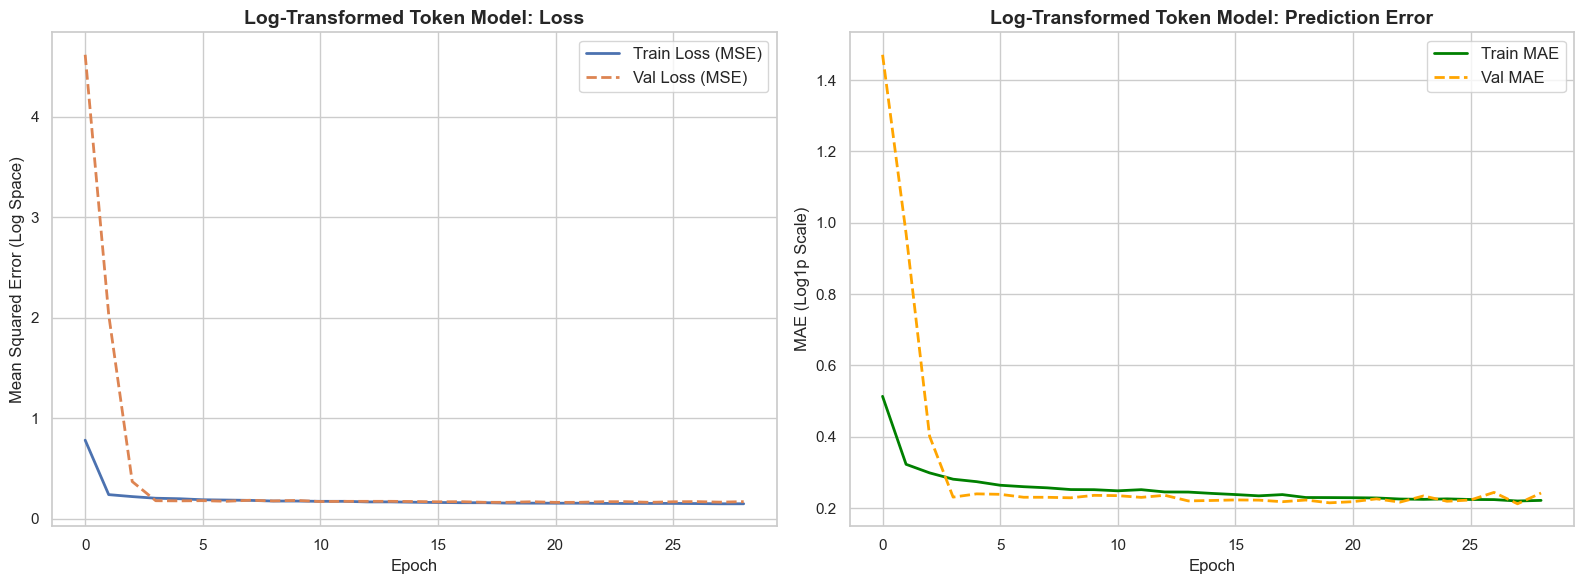

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean background style
sns.set_theme(style="whitegrid")

# Create a 1x2 layout for the log token model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# 1. Log Token Regressor: Loss (Mean Squared Error)
# ---------------------------------------------------------
axes[0].plot(history_token_log.history['loss'], label='Train Loss (MSE)', linewidth=2)
axes[0].plot(history_token_log.history['val_loss'], label='Val Loss (MSE)', linewidth=2, linestyle='--')
axes[0].set_title("Log-Transformed Token Model: Loss", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Mean Squared Error (Log Space)", fontsize=12)
axes[0].legend(fontsize=12)

# ---------------------------------------------------------
# 2. Log Token Regressor: Metric (Mean Absolute Error)
# ---------------------------------------------------------
axes[1].plot(history_token_log.history['mae'], label='Train MAE', linewidth=2, color='green')
axes[1].plot(history_token_log.history['val_mae'], label='Val MAE', linewidth=2, color='orange', linestyle='--')
axes[1].set_title("Log-Transformed Token Model: Prediction Error", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("MAE (Log1p Scale)", fontsize=12)
axes[1].legend(fontsize=12)

# Adjust spacing and display
plt.tight_layout()
plt.show()

Loading datasets...
Original data shape: (36497, 384)
Found 28 rows with NaN values. Filtering them out...
Train set shape: (29175, 384)
Validation set shape: (7294, 384)

Training Quality Model...
Epoch 1/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1668 - mae: 0.3448 - val_loss: 0.1975 - val_mae: 0.4273
Epoch 2/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1623 - mae: 0.3407 - val_loss: 0.1816 - val_mae: 0.4056
Epoch 3/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1614 - mae: 0.3403 - val_loss: 0.1640 - val_mae: 0.3604
Epoch 4/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1606 - mae: 0.3392 - val_loss: 0.1638 - val_mae: 0.3479
Epoch 5/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1604 - mae: 0.3393 - val_loss: 0.1628 - val_mae: 0.3365
Epoch 6/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1599 - mae: 0.3386 - val_loss: 0.1627 - val_mae: 0.3396
Epoch 7/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1598 - mae: 0.3382 - val_loss: 0

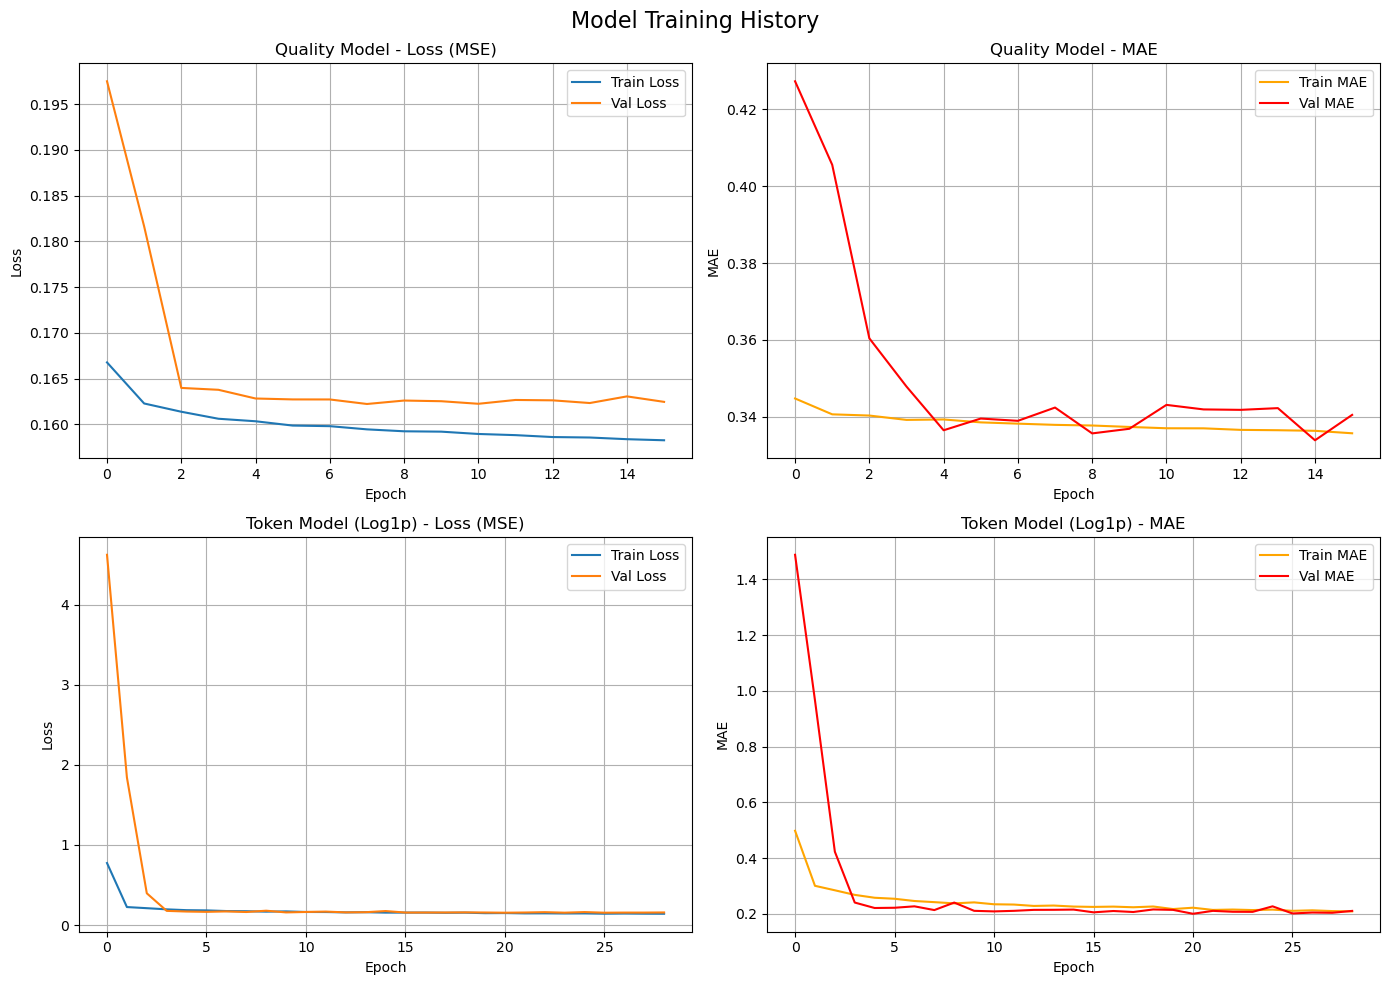

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def load_and_preprocess_data():
    """Loads features and targets, handles missing values, and splits data."""
    print("Loading datasets...")
    # 1. Load Data
    X = np.load('data/processed/X_embeddings.npy')
    df = pd.read_csv('data/processed/clean_router_data.csv')
    
    candidates = [
        "claude_instant", "claude_v1", "claude_v2", "code_llama_34b", 
        "gpt_35_turbo", "gpt_4", "llama_2_70b", "mistral_7b", 
        "mixtral_8x7b", "wizardlm_13b", "yi_34b"
    ]
    
    score_cols = [f"{c}_score" for c in candidates]
    token_cols = [f"{c}_tokens" for c in candidates]
    
    Y_scores = df[score_cols].values
    Y_tokens = df[token_cols].values
    
    # 2. Data Cleaning: Drop rows with NaN values in scores or tokens
    # Find rows where there is at least one NaN in scores or tokens
    nan_mask = np.isnan(Y_scores).any(axis=1) | np.isnan(Y_tokens).any(axis=1)
    
    print(f"Original data shape: {X.shape}")
    print(f"Found {nan_mask.sum()} rows with NaN values. Filtering them out...")
    
    X_clean = X[~nan_mask]
    Y_scores_clean = Y_scores[~nan_mask]
    Y_tokens_clean = Y_tokens[~nan_mask]
    
    # 3. Token Target Transformation
    Y_tokens_log = np.log1p(Y_tokens_clean)
    
    # 4. Data Splitting
    X_train, X_val, Y_scores_train, Y_scores_val, Y_tokens_train, Y_tokens_val = train_test_split(
        X_clean, Y_scores_clean, Y_tokens_log, test_size=0.2, random_state=42
    )
    
    print(f"Train set shape: {X_train.shape}")
    print(f"Validation set shape: {X_val.shape}")
    
    return X_train, X_val, Y_scores_train, Y_scores_val, Y_tokens_train, Y_tokens_val

def build_mlp_base():
    """Builds the shared base architecture for both models."""
    inputs = keras.Input(shape=(384,))
    x = layers.Dense(256, activation='gelu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Dense(128, activation='gelu')(x)
    return inputs, x

def build_quality_model():
    """Builds the Multi-Target Regression Model for Quality Scores."""
    inputs, x = build_mlp_base()
    outputs = layers.Dense(11, activation='sigmoid')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name="quality_model")
    optimizer = keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

def build_token_model():
    """Builds the Multi-Target Regression Model for Log-Transformed Token Counts."""
    inputs, x = build_mlp_base()
    outputs = layers.Dense(11, activation='relu')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name="token_model")
    optimizer = keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

def plot_training_history(history_quality, history_token):
    """Plots training and validation metrics in a 2x2 grid."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Model Training History', fontsize=16)
    
    # Quality Model Loss
    axes[0, 0].plot(history_quality.history['loss'], label='Train Loss')
    axes[0, 0].plot(history_quality.history['val_loss'], label='Val Loss')
    axes[0, 0].set_title('Quality Model - Loss (MSE)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Quality Model MAE
    axes[0, 1].plot(history_quality.history['mae'], label='Train MAE', color='orange')
    axes[0, 1].plot(history_quality.history['val_mae'], label='Val MAE', color='red')
    axes[0, 1].set_title('Quality Model - MAE')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('MAE')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Token Model Loss
    axes[1, 0].plot(history_token.history['loss'], label='Train Loss')
    axes[1, 0].plot(history_token.history['val_loss'], label='Val Loss')
    axes[1, 0].set_title('Token Model (Log1p) - Loss (MSE)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Token Model MAE
    axes[1, 1].plot(history_token.history['mae'], label='Train MAE', color='orange')
    axes[1, 1].plot(history_token.history['val_mae'], label='Val MAE', color='red')
    axes[1, 1].set_title('Token Model (Log1p) - MAE')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('MAE')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    os.makedirs('artifacts', exist_ok=True)
    plt.savefig('artifacts/training_history.png')
    print("Saved training history plot to 'artifacts/training_history.png'")
    # plt.show() # Uncomment if running interactively

def main():
    X_train, X_val, Y_scores_train, Y_scores_val, Y_tokens_train, Y_tokens_val = load_and_preprocess_data()
    
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=8, 
        restore_best_weights=True
    )
    
    os.makedirs('artifacts', exist_ok=True)
    
    # --- Train Quality Model ---
    print("\n" + "="*50)
    print("Training Quality Model...")
    print("="*50)
    quality_model = build_quality_model()
    history_quality = quality_model.fit(
        X_train, Y_scores_train,
        validation_data=(X_val, Y_scores_val),
        epochs=40,
        batch_size=128,
        callbacks=[early_stopping],
        verbose=1
    )
    quality_model.save('artifacts/quality_model.keras')
    print("Saved quality model to 'artifacts/quality_model.keras'")
    
    # --- Train Token Model ---
    print("\n" + "="*50)
    print("Training Token Model...")
    print("="*50)
    token_model = build_token_model()
    history_token = token_model.fit(
        X_train, Y_tokens_train,
        validation_data=(X_val, Y_tokens_val),
        epochs=40,
        batch_size=128,
        callbacks=[early_stopping],
        verbose=1
    )
    token_model.save('artifacts/token_model_log.keras')
    print("Saved token model to 'artifacts/token_model_log.keras'")
    
    # --- Plot History ---
    plot_training_history(history_quality, history_token)

if __name__ == "__main__":
    main()
